In [1]:
import pandas as pd
import numpy as np

import os
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as st

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint

import warnings

warnings.filterwarnings("ignore")

os.makedirs('images', exist_ok=True)

In [2]:
df = pd.read_csv("marketing_campaign_large.csv")

In [3]:
df.head()

,Date,Facebook_Ad_Campaign,Facebook_Ad_Views,Facebook_Ad_Clicks,Facebook_Ad_Conversions,Cost_Per_Facebook_Ad,AdWords_Ad_Campaign,AdWords_Ad_Views,AdWords_Ad_Clicks,AdWords_Ad_Conversions,Cost_Per_AdWords_Ad,Facebook_CTR,Facebook_Conversion_Rate,Facebook_CPC,AdWords_CTR,AdWords_Conversion_Rate,AdWords_CPC
0,2019-01-01,FB_Jan19,171736,5563,441,5563.00,AW_Jan19,80881,2865,101,4498.05,3.24,7.94,1.00,3.54,3.53,1.57
1,2019-01-02,FB_Jan19,144940,2628,279,1655.64,AW_Jan19,81318,2717,96,6765.33,1.81,10.63,0.63,3.34,3.54,2.49
2,2019-01-03,FB_Jan19,152397,3866,262,2164.96,AW_Jan19,101935,3921,97,9331.98,2.54,6.80,0.56,3.85,2.49,2.38
3,2019-01-04,FB_Jan19,142706,3657,292,3437.58,AW_Jan19,67806,3191,118,5360.88,2.56,8.00,0.94,4.71,3.72,1.68
4,2019-01-05,FB_Jan19,193700,5302,446,4718.78,AW_Jan19,92033,2155,91,4094.50,2.74,8.43,0.89,2.34,4.26,1.90


In [4]:
df.shape

(1096, 17)

In [5]:
df.dtypes

Date                            str
Facebook_Ad_Campaign            str
Facebook_Ad_Views             int64
Facebook_Ad_Clicks            int64
Facebook_Ad_Conversions       int64
Cost_Per_Facebook_Ad        float64
AdWords_Ad_Campaign             str
AdWords_Ad_Views              int64
AdWords_Ad_Clicks             int64
AdWords_Ad_Conversions        int64
Cost_Per_AdWords_Ad         float64
Facebook_CTR                float64
Facebook_Conversion_Rate    float64
Facebook_CPC                float64
AdWords_CTR                 float64
AdWords_Conversion_Rate     float64
AdWords_CPC                 float64
dtype: object

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df['Date'].dtype

dtype('<M8[us]')

In [8]:
df.describe()

,Date,Facebook_Ad_Views,Facebook_Ad_Clicks,Facebook_Ad_Conversions,Cost_Per_Facebook_Ad,AdWords_Ad_Views,AdWords_Ad_Clicks,AdWords_Ad_Conversions,Cost_Per_AdWords_Ad,Facebook_CTR,Facebook_Conversion_Rate,Facebook_CPC,AdWords_CTR,AdWords_Conversion_Rate,AdWords_CPC
count,1096,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,2020-07-01 12:00:00,176551.715328,4941.936131,484.813869,3171.693175,93778.904197,4233.844891,206.895985,8827.537737,2.761268,9.578349,0.663221,4.455511,4.785310,2.152692
min,2019-01-01 00:00:00,80332.000000,1303.000000,81.000000,689.720000,30000.000000,1066.000000,32.000000,2144.230000,1.140000,3.410000,0.300000,1.500000,1.500000,0.900000
25%,2019-10-01 18:00:00,149876.750000,3610.500000,296.000000,2320.202500,76233.000000,3015.750000,124.000000,6489.945000,2.320000,7.810000,0.550000,3.677500,3.770000,1.790000
50%,2020-07-01 12:00:00,173963.500000,4686.000000,429.000000,3081.890000,91814.000000,3971.000000,176.000000,8437.080000,2.690000,9.285000,0.650000,4.350000,4.705000,2.110000
75%,2021-04-01 06:00:00,200914.500000,6008.000000,636.000000,3828.947500,109140.000000,5191.500000,263.250000,10524.100000,3.170000,11.237500,0.770000,5.172500,5.690000,2.470000
max,2021-12-31 00:00:00,311961.000000,13690.000000,2079.000000,10541.300000,172466.000000,10875.000000,813.000000,25586.880000,5.060000,22.000000,1.190000,8.440000,10.450000,3.970000
std,NaN,39335.973584,1814.664852,249.724246,1137.052338,23471.399437,1663.412930,117.398926,3339.036506,0.644305,2.497293,0.163656,1.080125,1.440383,0.502768


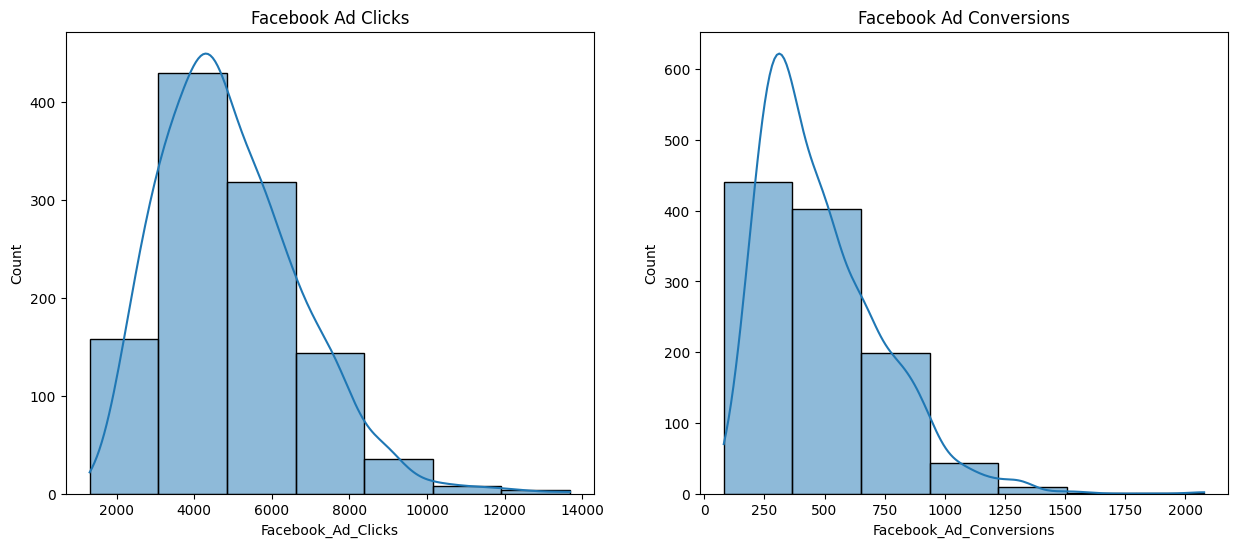

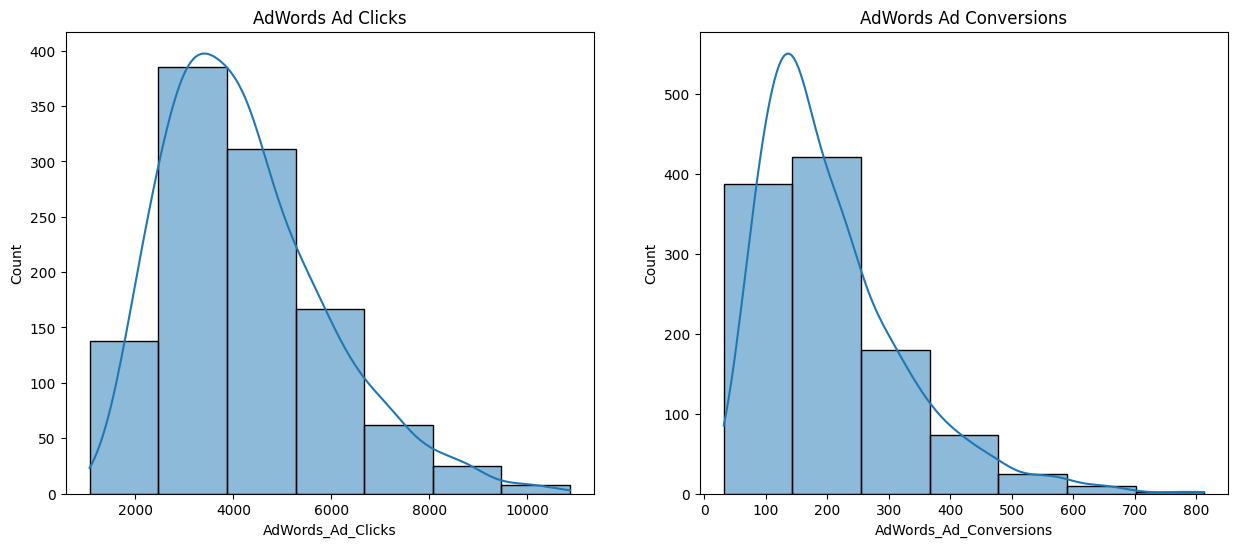

In [9]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['Facebook_Ad_Clicks'], bins=7, edgecolor='k', kde=True)

plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['Facebook_Ad_Conversions'], bins=7, edgecolor='k', kde=True)

plt.savefig('images/facebook_ad_histograms.png', bbox_inches='tight')
plt.show()


plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('AdWords Ad Clicks')
sns.histplot(df['AdWords_Ad_Clicks'], bins=7, edgecolor='k', kde=True)

plt.subplot(1,2,2)
plt.title('AdWords Ad Conversions')
sns.histplot(df['AdWords_Ad_Conversions'], bins=7, edgecolor='k', kde=True)

plt.savefig('images/adwords_ad_histograms.png', bbox_inches='tight')
plt.show()

In [10]:
def create_conversion_category(conversion_col):
    category = []

    for conversion in df[conversion_col]:
        if conversion < 20:
            category.append('less than 20')

        elif 20 <= conversion < 40:
            category.append('20 - 39')

        elif 40 <= conversion < 60:
            category.append('40 - 59')

        else:
            category.append('more than 60')

    return category

df['Facebook_Conversion_Category'] = create_conversion_category('Facebook_Ad_Conversions')

df['AdWords_Conversion_Category'] = create_conversion_category('AdWords_Ad_Conversions')

In [11]:
df[['Facebook_Ad_Conversions',
    'Facebook_Conversion_Category',
    'AdWords_Ad_Conversions',
    'AdWords_Conversion_Category']].head()

,Facebook_Ad_Conversions,Facebook_Conversion_Category,AdWords_Ad_Conversions,AdWords_Conversion_Category
0,441,more than 60,101,more than 60
1,279,more than 60,96,more than 60
2,262,more than 60,97,more than 60
3,292,more than 60,118,more than 60
4,446,more than 60,91,more than 60


In [12]:
df['Facebook_Conversion_Category'].value_counts()

Facebook_Conversion_Category
more than 60    1096
Name: count, dtype: int64

In [13]:
facebook = (
    pd.DataFrame(df['Facebook_Conversion_Category'].value_counts())
    .reset_index()
    .rename(columns={
        'Facebook_Conversion_Category': 'Count',
        'index': 'Category'
    })
)

facebook

,Count,count
0,more than 60,1096


In [14]:
df['AdWords_Conversion_Category'].value_counts()

AdWords_Conversion_Category
more than 60    1075
40 - 59           20
20 - 39            1
Name: count, dtype: int64

In [15]:
adwords = (
    pd.DataFrame(df['AdWords_Conversion_Category'].value_counts())
    .reset_index()
    .rename(columns={
        'AdWords_Conversion_Category': 'Count',
        'index': 'Category'
    })
)

adwords

,Count,count
0,more than 60,1075
1,40 - 59,20
2,20 - 39,1


In [16]:
facebook = df['Facebook_Conversion_Category'].value_counts().reset_index()
facebook.columns = ['Category', 'Facebook_Count']

adwords = df['AdWords_Conversion_Category'].value_counts().reset_index()
adwords.columns = ['Category', 'AdWords_Count']

In [17]:
category_df = pd.merge(
    facebook,
    adwords,
    on='Category',
    how='outer'
).fillna(0)

category_df

,Category,Facebook_Count,AdWords_Count
0,20 - 39,0.0,1
1,40 - 59,0.0,20
2,more than 60,1096.0,1075


In [18]:
desired_order = ['less than 20', '20 - 39', '40 - 59', 'more than 60']

category_df = (
    category_df
    .set_index('Category')
    .reindex(desired_order, fill_value=0)
    .reset_index()
)

category_df

,Category,Facebook_Count,AdWords_Count
0,less than 20,0.0,0
1,20 - 39,0.0,1
2,40 - 59,0.0,20
3,more than 60,1096.0,1075


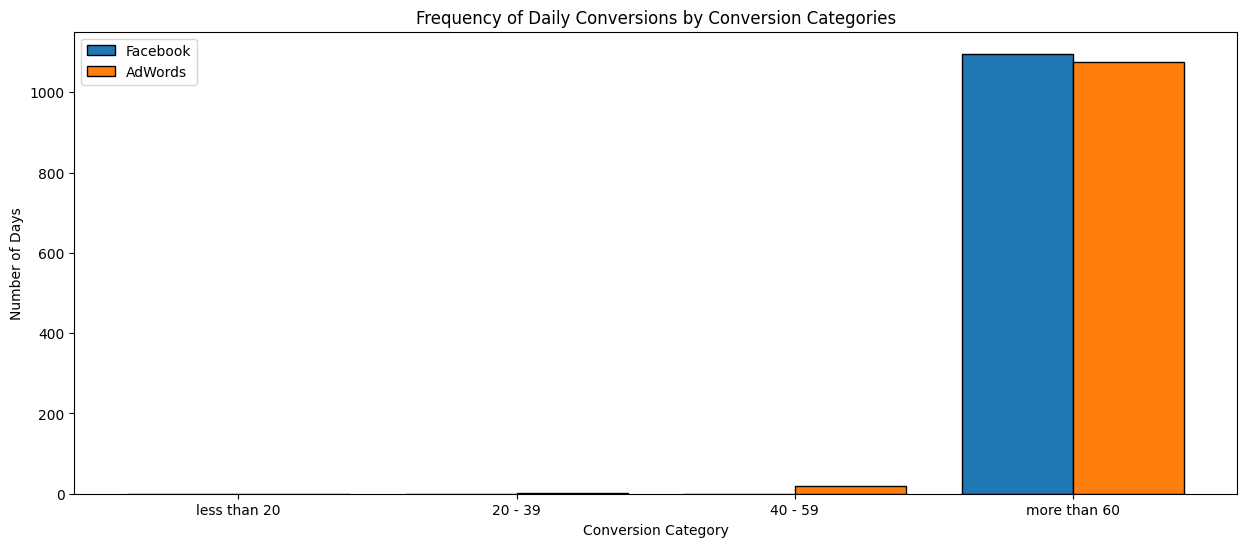

In [19]:
X_axis = np.arange(len(category_df))

plt.figure(figsize=(15,6))

plt.bar(
    X_axis - 0.2,
    category_df['Facebook_Count'],
    0.4,
    label='Facebook',
    edgecolor='k'
)

plt.bar(
    X_axis + 0.2,
    category_df['AdWords_Count'],
    0.4,
    label='AdWords',
    edgecolor='k'
)

plt.xticks(X_axis, category_df['Category'])
plt.xlabel("Conversion Category")
plt.ylabel("Number of Days")
plt.title("Frequency of Daily Conversions by Conversion Categories")
plt.legend()
plt.savefig('images/conversion_category_frequency.png', bbox_inches='tight')

plt.show()

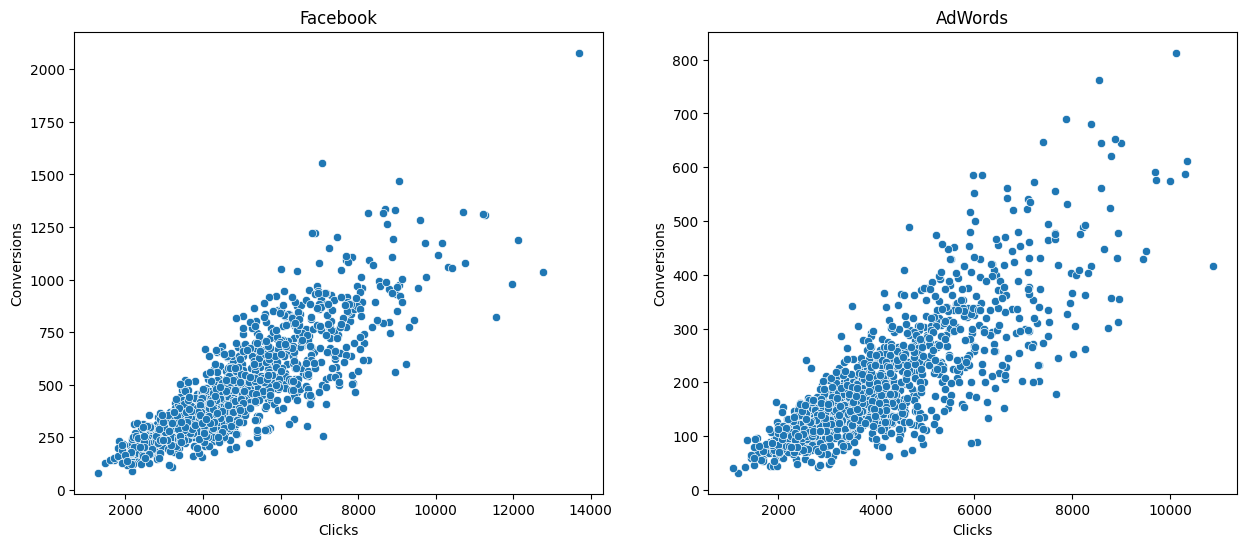

In [20]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(
    x=df['Facebook_Ad_Clicks'],
    y=df['Facebook_Ad_Conversions']
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.subplot(1,2,2)
plt.title('AdWords')
sns.scatterplot(
    x=df['AdWords_Ad_Clicks'],
    y=df['AdWords_Ad_Conversions']
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.savefig('images/clicks_vs_conversions_scatter.png', bbox_inches='tight')
plt.show()

In [21]:
facebook_corr = df[['Facebook_Ad_Conversions', 'Facebook_Ad_Clicks']].corr()

facebook_corr

,Facebook_Ad_Conversions,Facebook_Ad_Clicks
Facebook_Ad_Conversions,1.000000,0.849551
Facebook_Ad_Clicks,0.849551,1.000000


In [22]:
adwords_corr = df[['AdWords_Ad_Conversions', 'AdWords_Ad_Clicks']].corr()

adwords_corr

,AdWords_Ad_Conversions,AdWords_Ad_Clicks
AdWords_Ad_Conversions,1.000000,0.813973
AdWords_Ad_Clicks,0.813973,1.000000


In [23]:
print('Correlation Coeff\n----------------')

print('Facebook :', round(facebook_corr.values[0,1], 2))
print('AdWords  :', round(adwords_corr.values[0,1], 2))

Correlation Coeff
----------------
Facebook : 0.85
AdWords  : 0.81


In [24]:
print('Mean Conversion\n----------------')

print('Facebook :', round(df['Facebook_Ad_Conversions'].mean(), 2))
print('AdWords  :', round(df['AdWords_Ad_Conversions'].mean(), 2))


t_stats, p_value = st.ttest_ind(
    a=df['Facebook_Ad_Conversions'],
    b=df['AdWords_Ad_Conversions'],
    equal_var=False
)

print('\nT statistic:', t_stats)
print('P-value:', p_value)


# comparing the p-value with significance level of 0.05

if p_value < 0.05:
    print('\nP-value is less than significance value, Reject the null hypothesis')
else:
    print('\nP-value is greater than significance value, Accept the null hypothesis')

Mean Conversion
----------------
Facebook : 484.81
AdWords  : 206.9

T statistic: 33.342787945324936
P-value: 2.122073631094319e-184

P-value is less than significance value, Reject the null hypothesis


In [25]:
# independent variable

X = df[['Facebook_Ad_Clicks']]

# dependent variable

y = df[['Facebook_Ad_Conversions']]

# initializing and fitting Linear Regression model

reg_model = LinearRegression()

reg_model.fit(X, y)

prediction = reg_model.predict(X)

# model evaluation

r2 = r2_score(y, prediction) * 100

mse = mean_squared_error(y, prediction)

print('Accuracy (R2 Score):', round(r2, 2), '%')
print('Mean Squared Error:', round(mse, 2))

Accuracy (R2 Score): 72.17 %
Mean Squared Error: 17337.24


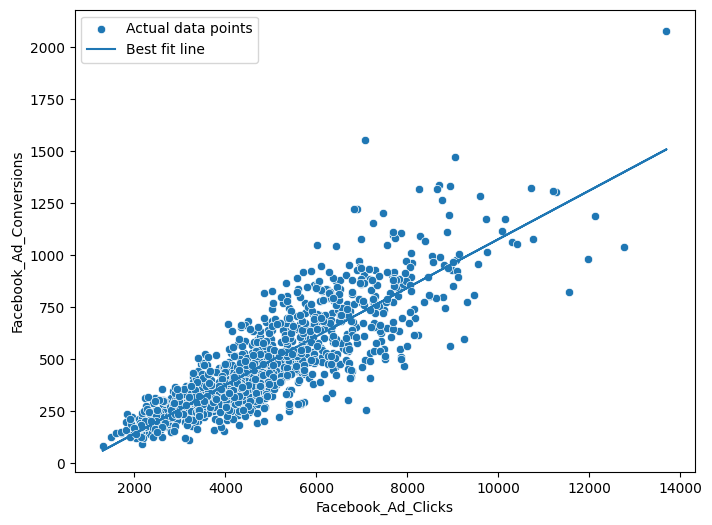

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Facebook_Ad_Clicks'],
    y=df['Facebook_Ad_Conversions'],
    label='Actual data points'
)

plt.plot(
    df['Facebook_Ad_Clicks'],
    prediction,
    label='Best fit line'
)

plt.legend()
plt.savefig('images/facebook_clicks_vs_conversions_regression.png', bbox_inches='tight')

plt.show()

In [27]:
print(f'For 50 Clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0], 2)}')

print(f'For 80 Clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0], 2)}')

For 50 Clicks, Expected Conversion : -87.11
For 80 Clicks, Expected Conversion : -83.6


In [28]:
# extracting month and week day from the date column

df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.weekday

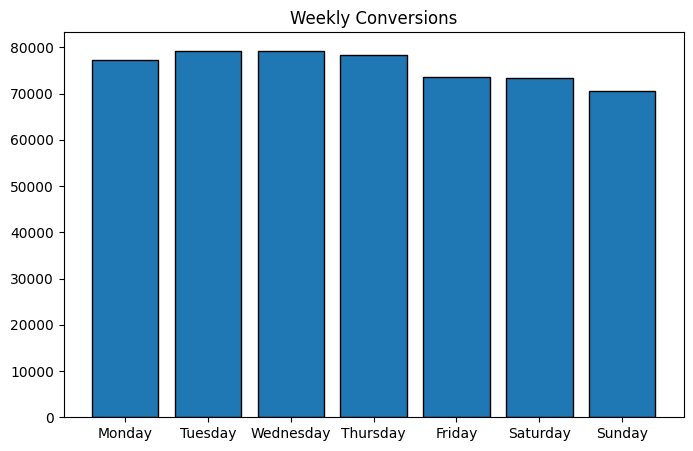

In [29]:
plt.figure(figsize=(8,5))

plt.title('Weekly Conversions')

weekly_conversion = df.groupby('week')[['Facebook_Ad_Conversions']].sum()

week_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.bar(
    week_names,
    weekly_conversion['Facebook_Ad_Conversions'],
    edgecolor='k'
)

plt.savefig('images/weekly_conversions.png', bbox_inches='tight')
plt.show()

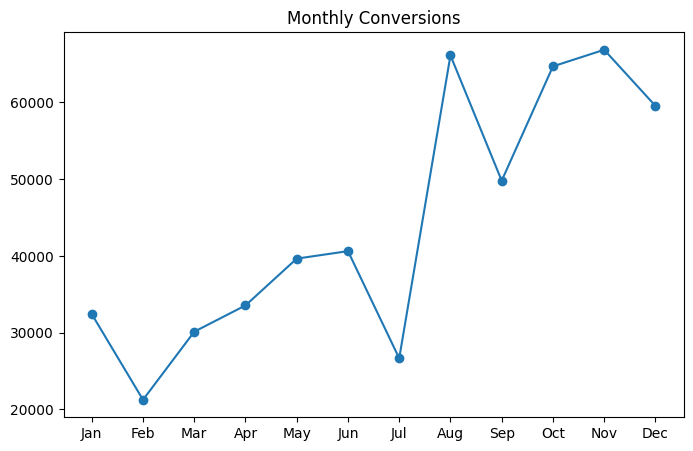

In [30]:
plt.figure(figsize=(8,5))

plt.title('Monthly Conversions')

monthly_conversion = df.groupby('month')[['Facebook_Ad_Conversions']].sum()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.plot(
    month_names,
    monthly_conversion['Facebook_Ad_Conversions'],
    '-o'
)

plt.savefig('images/monthly_conversions.png', bbox_inches='tight')
plt.show()

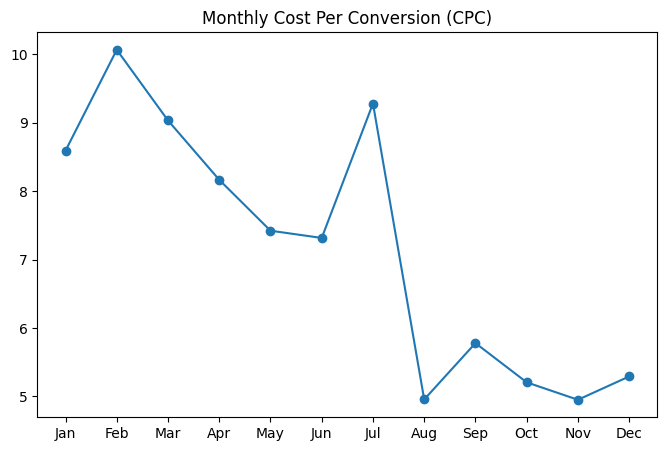

In [31]:
plt.figure(figsize=(8,5))

plt.title('Monthly Cost Per Conversion (CPC)')

monthly_df = df.groupby('month')[['Facebook_Ad_Conversions', 'Cost_Per_Facebook_Ad']].sum()

monthly_df['Cost_Per_Conversion'] = (
    monthly_df['Cost_Per_Facebook_Ad'] /
    monthly_df['Facebook_Ad_Conversions']
)

plt.plot(
    month_names,
    monthly_df['Cost_Per_Conversion'],
    '-o'
)

plt.savefig('images/monthly_cost_per_conversion.png', bbox_inches='tight')
plt.show()

In [32]:
score, p_value, _ = coint(
    df['Cost_Per_Facebook_Ad'],
    df['Facebook_Ad_Conversions']
)

print('Cointegration test score:', score)
print('P-value:', p_value)

if p_value < 0.05:
    print('\nP-value is less than significance value, Reject the null hypothesis')
else:
    print('\nP-value is greater than significance value, Accept the null hypothesis')

Cointegration test score: -21.770409184388694
P-value: 0.0

P-value is less than significance value, Reject the null hypothesis
